# 03 — Nutrition Health Scorer: XGBoost Classifier

**Model:** XGBoost 3-class classifier (POOR / MODERATE / GOOD)
- Input: total nutrition dari makanan yang di-scan + user goal + kondisi medis
- Output: health assessment + confidence score

**Training data:** 5,000 synthetic meal records (rule-based labeling)

**Output:**
- `output/models/nutrition_scorer.pkl`
- `output/models/scanner_config.json`

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import os
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import seaborn as sns
optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)
os.makedirs('output/models', exist_ok=True)

# Load food data untuk generate training records
df_food = pd.read_parquet('output/preprocessed/food_processed.parquet')
print(f'Foods: {df_food.shape}')

# Load diet recommendations untuk validasi thresholds
DIET_PATH = '../../dataset/Model_Perencana Makan_dan_Nutrisi/Diet Recommendations Dataset/diet_recommendations_dataset.csv'
df_diet = pd.read_csv(DIET_PATH)
print(f'Diet recs: {df_diet.shape}')
df_diet.head(3)

Foods: (1346, 12)
Diet recs: (1000, 20)


,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Dietary_Restrictions,Allergies,Preferred_Cuisine,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Diet_Recommendation
0,P0001,56,Male,58.4,160,22.8,Obesity,Moderate,Moderate,3079,173.3,133,116.3,NaN,Peanuts,Mexican,3.1,96.6,3.1,Balanced
1,P0002,69,Male,101.2,169,35.4,Diabetes,Mild,Moderate,3032,199.2,120,137.1,NaN,Peanuts,Chinese,4.5,63.2,0.6,Low_Carb
2,P0003,46,Female,63.5,173,21.2,Hypertension,Mild,Sedentary,1737,181.0,121,109.6,NaN,Peanuts,Chinese,3.8,57.5,4.6,Low_Sodium


In [2]:
# ── 1. Nutrition Thresholds per Goal ──
GOAL_NUTRITION_RULES = {
    'WEIGHT_LOSS': {
        'cal_max_per_meal':     500,
        'protein_min_per_meal': 25,
        'fat_max_per_meal':     15,
        'carbs_max_per_meal':   65,
    },
    'MUSCLE_GAIN': {
        'cal_min_per_meal':     400,
        'protein_min_per_meal': 35,
        'fat_max_per_meal':     20,
        'carbs_min_per_meal':   55,
    },
    'MAINTENANCE': {
        'cal_max_per_meal':     600,
        'protein_min_per_meal': 20,
        'fat_max_per_meal':     20,
        'carbs_max_per_meal':   80,
    },
    'PERFORMANCE': {
        'cal_min_per_meal':     450,
        'protein_min_per_meal': 30,
        'fat_max_per_meal':     18,
        'carbs_min_per_meal':   60,
    },
}

GOALS      = ['WEIGHT_LOSS', 'MUSCLE_GAIN', 'MAINTENANCE', 'PERFORMANCE']
CONDITIONS = ['None', 'None', 'None', 'Diabetes', 'Hypertension', 'Obesity']

print('Goals:', GOALS)
print('Conditions (weighted):', CONDITIONS)

Goals: ['WEIGHT_LOSS', 'MUSCLE_GAIN', 'MAINTENANCE', 'PERFORMANCE']
Conditions (weighted): ['None', 'None', 'None', 'Diabetes', 'Hypertension', 'Obesity']


In [3]:
# ── 2. Generate Synthetic Training Data ──
def compute_label(total_cal, total_protein, total_fat, total_carbs, goal, condition):
    """Rule-based label generation sesuai nutrition thresholds."""
    rules = GOAL_NUTRITION_RULES[goal]
    good_flags = 0
    total_flags = 0

    checks = [
        ('cal_max_per_meal',     lambda: total_cal     <= rules.get('cal_max_per_meal', 9999)),
        ('cal_min_per_meal',     lambda: total_cal     >= rules.get('cal_min_per_meal', 0)),
        ('protein_min_per_meal', lambda: total_protein >= rules.get('protein_min_per_meal', 0)),
        ('fat_max_per_meal',     lambda: total_fat     <= rules.get('fat_max_per_meal', 9999)),
        ('carbs_max_per_meal',   lambda: total_carbs   <= rules.get('carbs_max_per_meal', 9999)),
        ('carbs_min_per_meal',   lambda: total_carbs   >= rules.get('carbs_min_per_meal', 0)),
    ]
    for key, check_fn in checks:
        if key in rules:
            total_flags += 1
            if check_fn(): good_flags += 1

    ratio = good_flags / max(total_flags, 1)
    if ratio >= 0.75:   label = 2  # GOOD
    elif ratio >= 0.45: label = 1  # MODERATE
    else:               label = 0  # POOR

    # Disease overrides
    if condition == 'Diabetes'     and total_carbs > 55: label = max(0, label - 1)
    if condition == 'Hypertension' and total_fat   > 25: label = max(0, label - 1)
    if condition == 'Obesity'      and total_cal   > 550: label = max(0, label - 1)

    return label

records = []
np.random.seed(42)
for _ in range(5000):
    n_foods   = np.random.randint(1, 5)
    foods     = df_food.sample(n=n_foods)
    goal      = np.random.choice(GOALS)
    condition = np.random.choice(CONDITIONS)
    portions  = np.random.uniform(0.5, 2.0, size=n_foods)

    total_cal     = float((foods['calories_per_portion'].values * portions).sum())
    total_protein = float((foods['protein_g'].values * portions).sum())
    total_fat     = float((foods['fat_g'].values * portions).sum())
    total_carbs   = float((foods['carbs_g'].values * portions).sum())

    label = compute_label(total_cal, total_protein, total_fat, total_carbs, goal, condition)

    records.append({
        'total_cal':     round(total_cal, 2),
        'total_protein': round(total_protein, 2),
        'total_fat':     round(total_fat, 2),
        'total_carbs':   round(total_carbs, 2),
        'n_foods':       n_foods,
        'goal_enc':      GOALS.index(goal),
        'condition_enc': {'None': 0, 'Diabetes': 1, 'Hypertension': 2, 'Obesity': 3}[condition],
        'label':         label,
    })

df_train = pd.DataFrame(records)
print(f'Training data: {df_train.shape}')
print(f'Label distribution: {df_train["label"].value_counts().sort_index().to_dict()}')
print(f'  0=POOR, 1=MODERATE, 2=GOOD')

Training data: (5000, 8)
Label distribution: {0: 2040, 1: 1387, 2: 1573}
  0=POOR, 1=MODERATE, 2=GOOD


In [4]:
# ── 3. Train/Test Split ──
FEATURES = ['total_cal', 'total_protein', 'total_fat', 'total_carbs',
            'n_foods', 'goal_enc', 'condition_enc']

X = df_train[FEATURES]
y = df_train['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Train labels: {dict(y_train.value_counts().sort_index())}')

Train: (4000, 7)  Test: (1000, 7)
Train labels: {0: 1632, 1: 1110, 2: 1258}


In [5]:
# ── 4. Optuna Tuning ──
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('lr',    0.05, 0.3, log=True),
        'max_depth':     trial.suggest_int('depth',   3, 8),
        'n_estimators':  trial.suggest_int('n_est',   50, 300, step=50),
        'subsample':     trial.suggest_float('sub',   0.7, 1.0),
        'colsample_bytree': trial.suggest_float('col', 0.7, 1.0),
    }
    model = XGBClassifier(**params, random_state=42, eval_metric='mlogloss',
                          tree_method='hist', verbosity=0)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return f1_score(y_test, pred, average='macro', zero_division=0)

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f'\nBest CV F1-macro: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

  0%|          | 0/20 [00:00<?, ?it/s]


Best CV F1-macro: 0.9560
Best params: {'lr': 0.13744699059132842, 'depth': 6, 'n_est': 150, 'sub': 0.7960159126528711, 'col': 0.9428736755059343}


=== NUTRITION SCORER HASIL ===
F1-macro: 0.9567  (target >= 0.75)

              precision    recall  f1-score   support

        POOR       0.97      0.97      0.97       408
    MODERATE       0.92      0.93      0.93       277
        GOOD       0.97      0.97      0.97       315

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



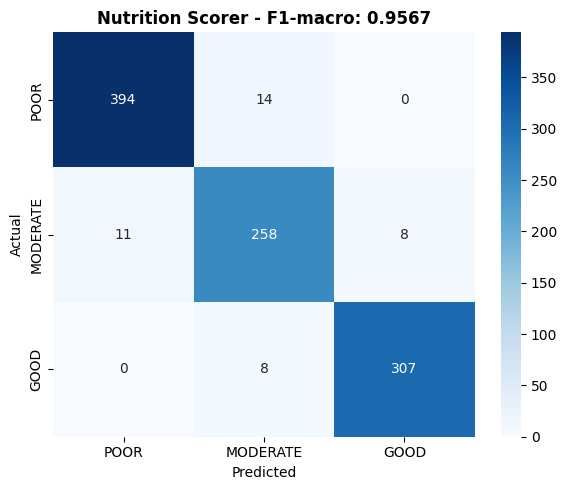

In [6]:
# ── 5. Train Final Model ──
scorer = XGBClassifier(**study.best_params, random_state=42,
                        eval_metric='mlogloss', tree_method='hist', verbosity=0)
scorer.fit(X_train, y_train)
pred = scorer.predict(X_test)
f1   = f1_score(y_test, pred, average='macro', zero_division=0)

print(f'=== NUTRITION SCORER HASIL ===')
print(f'F1-macro: {f1:.4f}  (target >= 0.75)')
print()
print(classification_report(y_test, pred, target_names=['POOR', 'MODERATE', 'GOOD']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['POOR','MODERATE','GOOD'],
            yticklabels=['POOR','MODERATE','GOOD'])
ax.set_title(f'Nutrition Scorer - F1-macro: {f1:.4f}', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('output/models/nutrition_scorer_cm.png', dpi=150)
plt.show()

In [7]:
# ── 6. Save ──
joblib.dump(scorer, 'output/models/nutrition_scorer.pkl', compress=3)
print(f'nutrition_scorer.pkl: {os.path.getsize("output/models/nutrition_scorer.pkl")/1024:.1f} KB')

scoring_config = {
    'version':        '1.0',
    'features':       FEATURES,
    'label_map':      {'0': 'POOR', '1': 'MODERATE', '2': 'GOOD'},
    'goal_map':       {str(i): g for i, g in enumerate(GOALS)},
    'condition_map':  {'None': 0, 'Diabetes': 1, 'Hypertension': 2, 'Obesity': 3},
    'goal_rules':     GOAL_NUTRITION_RULES,
    'f1_macro':       round(float(f1), 4),
    'best_params':    study.best_params,
    'n_training':     len(df_train),
}
with open('output/models/scanner_config.json', 'w') as f:
    json.dump(scoring_config, f, indent=2)

print('\nOK Nutrition Scorer saved.')
print(json.dumps({'f1_macro': scoring_config['f1_macro'],
                  'label_map': scoring_config['label_map']}, indent=2))

nutrition_scorer.pkl: 290.3 KB

OK Nutrition Scorer saved.
{
  "f1_macro": 0.9567,
  "label_map": {
    "0": "POOR",
    "1": "MODERATE",
    "2": "GOOD"
  }
}
